<a href="https://colab.research.google.com/github/LielUziahu/Stylophora-pistillata-FPs/blob/main/Spat_cell_count_to_mean_area.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import numpy as np

def merge_cell_counts_with_size():
    # 1. Load the Data Files
    try:
        df_cell = pd.read_csv("combine_spat_cell_count.csv")
        df_summary = pd.read_csv("Morph_Size_Summary.csv")

        print("Files loaded successfully.")
    except FileNotFoundError as e:
        print(f"Error: {e}")
        return None, None # Return None for both dataframes on error

    # 2. Clean Column Names and Types
    # Remove any leading/trailing spaces from column headers
    df_cell.columns = df_cell.columns.str.strip()
    df_summary.columns = df_summary.columns.str.strip()

    # Clean the 'morph' column (key for matching)
    df_cell['morph'] = df_cell['morph'].astype(str).str.strip()
    df_summary['Morph'] = df_summary['Morph'].astype(str).str.strip()

    # Ensure numerical columns are numeric, handling any errors
    df_cell['temp'] = pd.to_numeric(df_cell['temp'], errors='coerce').fillna(23).astype(int)

    # Ensure string columns are clean
    df_cell['pH'] = df_cell['pH'].astype(str).str.strip()
    df_cell['light'] = df_cell['light'].astype(str).str.strip()

    # 3. Define Logic to Match Conditions
    # This function translates your raw data (e.g., Temp=32) into the "Condition" label
    # used in the Summary Table (e.g., "32°C").
    def get_condition_key(row):
        temp = row['temp']
        ph = row['pH']
        light = row['light']

        # Check for Temperature Deviations
        if temp == 27: return "27"
        if temp == 32: return "32"

        # Check for pH Deviations
        if ph in ['7.6', '7.8']: return f"pH {ph}"

        # Check for Light Deviations
        if light == '50m': return "50m"
        if light == 'Dark': return "Dark"

        # If no deviations, it is the Control/Ambient group
        return "Ambient (Control)"

    # Apply the logic to create a matching key
    df_cell['Target_Condition'] = df_cell.apply(get_condition_key, axis=1)

    # 4. Prepare the Summary Table for Merging
    # We rename columns to make the merge clean and avoid duplicate names
    df_summary_clean = df_summary[['Condition', 'Morph', 'Mean Size (mm^2)', 'SD']].rename(
        columns=
            {
                'Condition': 'Target_Condition',
                'Morph': 'morph',
                'Mean Size (mm^2)': 'Mean_Size_mm2',
                'SD': 'Size_SD'
            }

    )

    # Clean the 'Target_Condition' in df_summary_clean to remove '°C' for matching
    df_summary_clean['Target_Condition'] = df_summary_clean['Target_Condition'].astype(str).str.replace('°C', '', regex=False).str.strip()

    # Remove any duplicates in the summary table to prevent row explosion
    df_summary_clean = df_summary_clean.drop_duplicates(subset=['Target_Condition', 'morph'])

    # 5. Perform the Merge (Left Join)
    # We keep all rows from your Cell Count file (Left) and attach matching size data (Right)
    df_merged = pd.merge(
        df_cell,
        df_summary_clean,
        on=['Target_Condition', 'morph'],
        how='left'
    )

    # 6. Save the Result
    output_filename = "combine_spat_cell_count_with_size.csv"
    df_merged.to_csv(output_filename, index=False)

    print(f"\nSuccess! Merged data saved to: {output_filename}")
    print("\nPreview of the new columns:")
    print(df_merged[['Sample No', 'morph', 'Target_Condition', 'Mean_Size_mm2', 'Size_SD']].head())

    return df_cell, df_merged # Return the dataframes

# Run the function and assign the results to global variables
global df_cell, df_merged
df_cell, df_merged = merge_cell_counts_with_size()

Files loaded successfully.

Success! Merged data saved to: combine_spat_cell_count_with_size.csv

Preview of the new columns:
   Sample No morph Target_Condition  Mean_Size_mm2  Size_SD
0        401    HF               32          2.745    1.189
1        402    NF               32          3.255    1.262
2        403    NF               32          3.255    1.262
3        404    HF               27          3.163    1.911
4        405    HF               27          3.163    1.911



ANALYSIS REPORT: Ambient Conditions

--- Descriptive Statistics (Mean +/- SD) ---
           mean      std  count
morph                          
HF     19025.05  8502.25     19
NF     17835.38  8433.30     12
PF     15424.97  7915.04     17

--- ANOVA Results ---
                sum_sq    df         F   PR(>F)
C(morph)  1.186295e+08   2.0  0.864961  0.42795
Residual  3.085879e+09  45.0       NaN      NaN

--- Tukey HSD Post-hoc ---
    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
group1 group2  meandiff  p-adj     lower      upper   reject
------------------------------------------------------------
    HF     NF -1189.6687 0.9199  -8590.1507 6210.8134  False
    HF     PF  -3600.081 0.4014 -10300.4169 3100.2549  False
    NF     PF -2410.4123 0.7219  -9977.5302 5156.7056  False
------------------------------------------------------------


/tmp/ipython-input-608817033.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='morph', y=y_col, order=morph_order, palette=variant_colors,
/tmp/ipython-input-608817033.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x='morph', y=y_col, order=morph_order, palette=variant_colors,


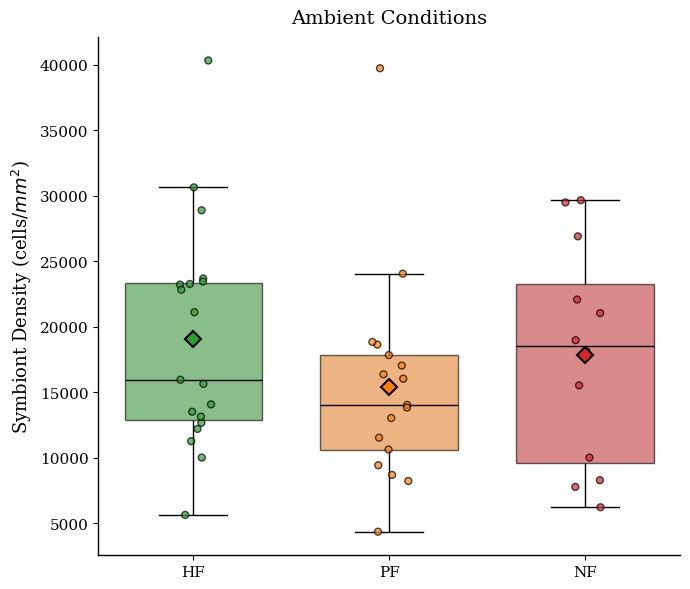

Plot saved: Ambient_Plot_Full.png

ANALYSIS REPORT: Symbiont Density by pH
Filter: PF morphs removed.

--- Descriptive Statistics (Mean +/- SD) ---
                     mean       std  count
Treatment morph                           
7.6       HF     26392.86  14787.61      4
          NF     35547.79  18955.08      2
7.8       HF     39856.80  27481.44      5
          NF     43410.09    536.20      3
8.2       HF     19025.05   8502.25     19
          NF     17835.38   8433.30     12

--- ANOVA Results ---
                             sum_sq    df          F    PR(>F)
C(Treatment)           3.462870e+09   2.0  11.033072  0.000159
C(morph)               9.693812e+06   1.0   0.061771  0.805022
C(Treatment):C(morph)  1.361392e+08   2.0   0.433754  0.651160
Residual               6.120323e+09  39.0        NaN       NaN

--- Tukey HSD Post-hoc ---
     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
group1 group2   meandiff  p-adj     lower      upper    reject
----------------

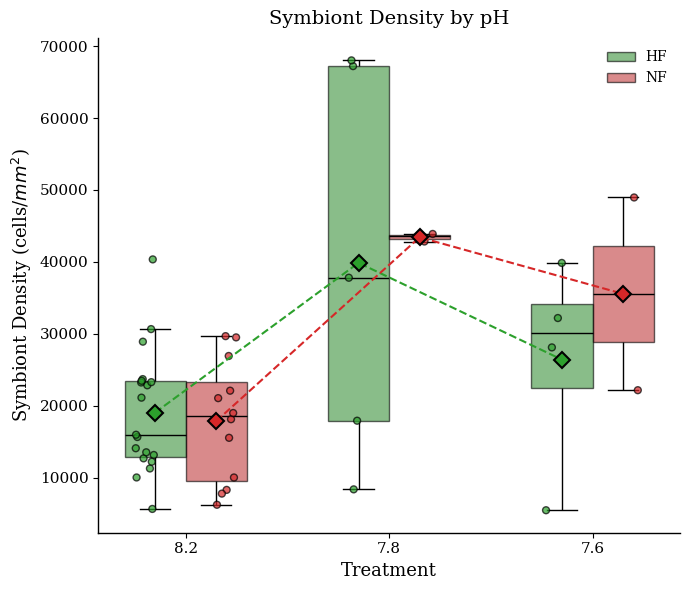

Plot saved: pH_Density_Plot.png

ANALYSIS REPORT: Symbiont Density by Temperature
Filter: PF morphs removed.

--- Descriptive Statistics (Mean +/- SD) ---
                     mean       std  count
Treatment morph                           
23        HF     19025.05   8502.25     19
          NF     17835.38   8433.30     12
27        HF     27558.23  13834.49      7
          NF     28050.04  16916.26      8
32        HF     11232.54   4492.61      3
          NF      9661.42   3320.58      4

--- ANOVA Results ---
                             sum_sq    df         F    PR(>F)
C(Treatment)           1.639806e+09   2.0  7.259280  0.001789
C(morph)               7.209210e+06   1.0  0.063829  0.801645
C(Treatment):C(morph)  8.334819e+06   2.0  0.036898  0.963803
Residual               5.308438e+09  47.0       NaN       NaN

--- Tukey HSD Post-hoc ---
     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
group1 group2   meandiff  p-adj     lower      upper    reject
--------------

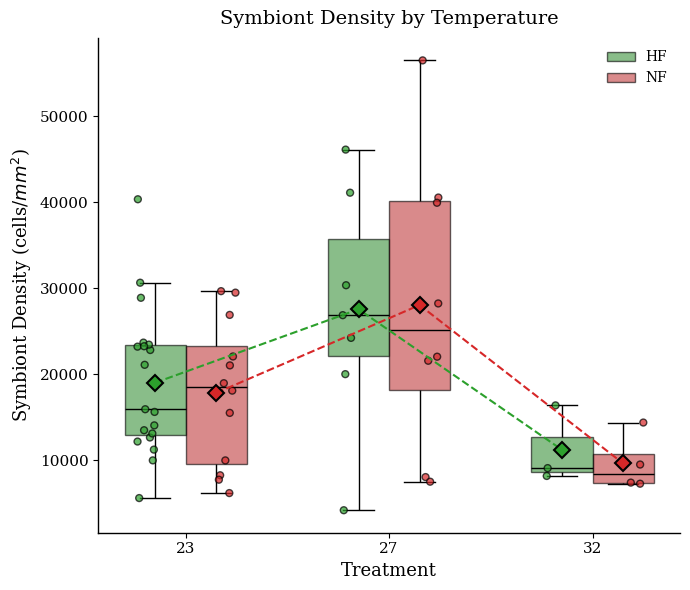

Plot saved: Temp_Density_Plot.png

ANALYSIS REPORT: Symbiont Density by Light
Filter: PF morphs removed.

--- Descriptive Statistics (Mean +/- SD) ---
                     mean      std  count
Treatment morph                          
10m       HF     19025.05  8502.25     19
          NF     17835.38  8433.30     12
50m       HF      9685.33  4592.90      7
          NF     10146.61  1849.33      5
Dark      HF      8783.49  5621.32      4
          NF     10619.49  7799.60      4

--- ANOVA Results ---
                             sum_sq    df         F    PR(>F)
C(Treatment)           9.246977e+08   2.0  8.318751  0.000843
C(morph)               1.135223e+06   1.0  0.020425  0.886994
C(Treatment):C(morph)  1.663659e+07   2.0  0.149666  0.861422
Residual               2.501061e+09  45.0       NaN       NaN

--- Tukey HSD Post-hoc ---
      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
 group1  group2   meandiff  p-adj     lower      upper    reject
----------------------

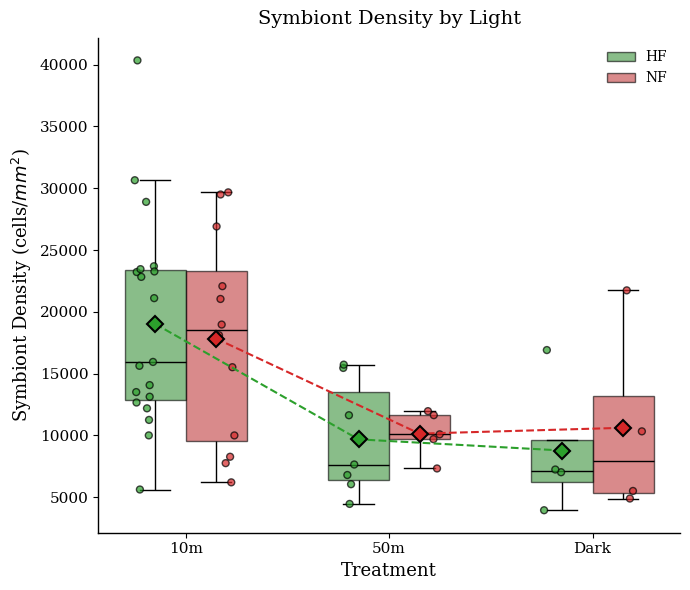

Plot saved: Light_Density_Plot.png


In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ==========================================
# 1. CONFIGURATION & STYLE
# ==========================================
plt.rcParams.update({
    'font.family': 'serif', 'axes.edgecolor': 'black', 'axes.linewidth': 1,
    'xtick.color': 'black', 'ytick.color': 'black', 'text.color': 'black',
    'axes.labelcolor': 'black', 'legend.frameon': False,
    'ytick.labelsize': 11, 'xtick.labelsize': 11
})

variant_colors = {'HF': '#2ca02c', 'NF': '#d62728', 'PF': '#ff7f0e'}
y_col = "Conc (cell/mm^2)"
y_label = "Symbiont Density (cells/$mm^2$)"

# ==========================================
# 2. MAIN ANALYSIS FUNCTION
# ==========================================
def analyze_and_plot_combined(filename, title, treatments_order, save_name, analysis_type="treatment"):
    print(f"\n{'='*60}")
    print(f"ANALYSIS REPORT: {title}")
    print(f"{'='*60}")

    try:
        # --- A. LOAD & CLEAN DATA ---
        df = pd.read_csv(filename)
        df.columns = df.columns.str.strip()

        # Ensure Numeric Y-Column
        if y_col not in df.columns:
             cols = [c for c in df.columns if "Conc" in c and "mm" in c]
             if cols: df.rename(columns={cols[0]: y_col}, inplace=True)
        df[y_col] = pd.to_numeric(df[y_col], errors='coerce')
        df = df.dropna(subset=[y_col])

        # Clean String Columns
        df['morph'] = df['morph'].astype(str).str.strip()
        if 'Treatment' in df.columns:
            df['Treatment'] = df['Treatment'].astype(str).str.strip()

        # --- B. FILTERING ---
        if analysis_type == "ambient":
            # AMBIENT: Keep ALL morphs (HF, NF, PF)
            pass
        else:
            # TREATMENTS: Remove PF
            df = df[df['morph'] != 'PF']
            print("Filter: PF morphs removed.")

        # --- C. STATISTICS ---
        if analysis_type == "ambient":
            groups = ['morph']
        else:
            groups = ['Treatment', 'morph']

        # 1. Descriptive Stats
        print("\n--- Descriptive Statistics (Mean +/- SD) ---")
        print(df.groupby(groups)[y_col].agg(['mean', 'std', 'count']).round(2))

        # 2. ANOVA
        # Construct formula dynamically
        formula = f"Q('{y_col}') ~ " + " + ".join([f"C({g})" for g in groups])
        if len(groups) > 1:
             formula += " + " + ":".join([f"C({g})" for g in groups])

        model = ols(formula, data=df).fit()
        print("\n--- ANOVA Results ---")
        print(sm.stats.anova_lm(model, typ=2))

        # 3. Post-hoc (Tukey HSD)
        print("\n--- Tukey HSD Post-hoc ---")
        if len(groups) > 1:
            df['group_col'] = df[groups[0]].astype(str) + "_" + df[groups[1]].astype(str)
        else:
            df['group_col'] = df[groups[0]].astype(str)

        tukey = pairwise_tukeyhsd(endog=df[y_col], groups=df['group_col'], alpha=0.05)
        print(tukey)

        # --- D. PLOTTING ---
        plt.figure(figsize=(7, 6))

        if analysis_type == "ambient":
            # === AMBIENT PLOT (Simple Boxplot) ===
            morph_order = ['HF', 'PF', 'NF']

            # Box
            sns.boxplot(data=df, x='morph', y=y_col, order=morph_order, palette=variant_colors,
                        width=0.7, showfliers=False, linewidth=1,
                        boxprops=dict(edgecolor='black', alpha=0.6),
                        whiskerprops=dict(color='black'), capprops=dict(color='black'), medianprops=dict(color='black'))

            # Jitter
            sns.stripplot(data=df, x='morph', y=y_col, order=morph_order, palette=variant_colors,
                          jitter=0.1, size=5, linewidth=1, edgecolor='black', alpha=0.7, zorder=3)

            # Mean Diamonds
            means = df.groupby('morph')[y_col].mean().reindex(morph_order)
            for i, m in enumerate(morph_order):
                plt.plot(i, means[m], marker='D', markersize=8, markerfacecolor=variant_colors[m],
                         markeredgecolor='black', markeredgewidth=1.5, zorder=4)
            plt.xlabel("")

        else:
            # === TREATMENT PLOT (Grouped Boxplot) ===
            morphs = ['HF', 'NF']
            t_order_str = [str(t) for t in treatments_order]

            # Box
            sns.boxplot(data=df, x='Treatment', y=y_col, hue='morph',
                        order=t_order_str, hue_order=morphs, palette=variant_colors,
                        width=0.6, showfliers=False, linewidth=1,
                        boxprops=dict(edgecolor='black', alpha=0.6),
                        whiskerprops=dict(color='black'), capprops=dict(color='black'), medianprops=dict(color='black'))

            # Jitter
            sns.stripplot(data=df, x='Treatment', y=y_col, hue='morph',
                          order=t_order_str, hue_order=morphs, palette=variant_colors,
                          dodge=True, jitter=True, size=5, linewidth=1, edgecolor='black', alpha=0.7, zorder=3)

            # Mean Diamonds & Lines (Manual Positioning)
            offset = 0.15
            morph_means = {m: {'pos': [], 'mean_val': []} for m in morphs}

            for i, treat in enumerate(t_order_str):
                for m in morphs:
                    sub = df[(df['Treatment'] == treat) & (df['morph'] == m)]
                    if not sub.empty:
                        mean_val = sub[y_col].mean()
                        pos = i + (-offset if m == 'HF' else offset)
                        # Plot mean diamond
                        plt.plot(pos, mean_val, marker='D', markersize=8, markerfacecolor=variant_colors[m],
                                 markeredgecolor='black', markeredgewidth=1.5, zorder=4)
                        # Store for line plotting
                        morph_means[m]['pos'].append(pos)
                        morph_means[m]['mean_val'].append(mean_val)

            # Plot dashed lines connecting means
            for m in morphs:
                if morph_means[m]['pos']:
                    plt.plot(morph_means[m]['pos'], morph_means[m]['mean_val'],
                             color=variant_colors[m], linestyle='--', linewidth=1.5, zorder=3)

            plt.xlabel("Treatment", size=13)

            # Clean Legend (Keep only first 2 items)
            handles, labels = plt.gca().get_legend_handles_labels()
            plt.legend(handles[:2], labels[:2], title=None, frameon=False)

        plt.ylabel(y_label, size=13)
        plt.title(title, size=14, pad=10)
        sns.despine()
        plt.tight_layout()
        plt.savefig(save_name, dpi=300)
        plt.show()
        print(f"Plot saved: {save_name}")

    except Exception as e:
        print(f"Error processing {filename}: {e}")

# ==========================================
# 3. EXECUTE ANALYSES
# ==========================================

# 1. AMBIENT (All Morphs)
analyze_and_plot_combined("Ambient_cell_area.csv", "Ambient Conditions", None, "Ambient_Plot_Full.png", analysis_type="ambient")

# 2. pH (No PF)
# Use exact string labels found in your CSV: '8.2', '7.8', '7.6'
analyze_and_plot_combined("pH_cell_area.csv", "Symbiont Density by pH", ['8.2', '7.8', '7.6'], "pH_Density_Plot.png", analysis_type="treatment")

# 3. Temp (No PF)
# Use exact string labels found in your CSV: '23', '27', '32'
analyze_and_plot_combined("Temp_cell_area.csv", "Symbiont Density by Temperature", ['23', '27', '32'], "Temp_Density_Plot.png", analysis_type="treatment")

# 4. Light (No PF)
# Use exact string labels found in your CSV: '10m', '50m', 'Dark'
analyze_and_plot_combined("Light_cell_area.csv", "Symbiont Density by Light", ['10m', '50m', 'Dark'], "Light_Density_Plot.png", analysis_type="treatment")
